<a href="https://colab.research.google.com/github/nastyabekesheva/Mathematical-Modeling/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install --upgrade "git+https://github.com/lisphilar/covid19-sir.git#egg=covsirphy"

  Cloning https://github.com/lisphilar/covid19-sir.git to /tmp/pip-install-uahonk7n/covsirphy_dcb1128202b6461e9762946ec11e5d52
  Running command git clone --filter=blob:none --quiet https://github.com/lisphilar/covid19-sir.git /tmp/pip-install-uahonk7n/covsirphy_dcb1128202b6461e9762946ec11e5d52
  Resolved https://github.com/lisphilar/covid19-sir.git to commit d70b5288f75d658e7cf8b479c8ebbe6dc6f2b8d0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [17]:
import covsirphy as cs
from datetime import timedelta
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
from matplotlib.ticker import ScalarFormatter

In [18]:
country = "Italy"
scenario = cs.ODEScenario.auto_build(geo=country, model=cs.SIRFModel)

2025-12-21 at 19:47:59 | INFO | 
<SIR-F Model: parameter estimation>
2025-12-21 at 19:47:59 | INFO | Running optimization with 8 CPUs...


100%|██████████| 124/124 [01:29<00:00,  1.39it/s]

2025-12-21 at 19:47:59 | INFO | Running optimization with 8 CPUs...


2025-12-21 at 19:49:28 | INFO | Completed optimization. Total: 1 min 29 sec



In [19]:
scenario.summary()

Start        End    Rt     theta     kappa       rho  \
Scenario Phase                                                             
Baseline 0th   2020-02-24 2020-03-22  7.48  0.039013  0.000474  0.017992   
         1st   2020-03-23 2020-04-10  2.63  0.022888  0.000626  0.004585   
         2nd   2020-04-11 2020-05-05   1.1  0.057529  0.000193  0.001832   
         3rd   2020-05-06 2020-08-28  0.31  0.019642  0.000101  0.000678   
         4th   2020-08-29 2020-09-25  3.07  0.004004   0.00002  0.002777   
...                   ...        ...   ...       ...       ...       ...   
         119th 2024-07-18 2024-07-30  3.07  0.017356  0.000002  0.002218   
         120th 2024-07-31 2024-08-15  2.74  0.026572  0.000008  0.001683   
         121st 2024-08-16 2024-09-01  2.78  0.025436  0.000008  0.001356   
         122nd 2024-09-02 2024-09-25  1.99  0.006366  0.000008   0.00115   
         123rd 2024-09-26 2024-10-16   2.8  0.000362  0.000002  0.000662   

                   sigma  alpha1 [-]  1/alpha2 [day]  1/beta [day]  \
Scenario Phase                                                       
Baseline 0th    0.001839       0.039             141             4   
         1st    0.001078       0.023             107            15   
         2nd    0.001382       0.058             346            36   
         3rd    0.002035        0.02             660            98   
         4th    0.000881       0.004            3255            24   
...                  ...         ...             ...           ...   
         119th  0.000708       0.017           38462            30   
         120th  0.000589       0.027            8543            40   
         121st  0.000468       0.025            8033            49   
         122nd  0.000567       0.006            8844            58   
         123rd  0.000234         0.0           34226           101   

                1/gamma [day]          ODE  tau  
Scenario Phase                                   
Baseline 0th               36  SIR-F Model   96  
         1st               62  SIR-F Model   96  
         2nd               48  SIR-F Model   96  
         3rd               33  SIR-F Model   96  
         4th               76  SIR-F Model   96  
...                       ...          ...  ...  
         119th             94  SIR-F Model   96  
         120th            113  SIR-F Model   96  
         121st            143  SIR-F Model   96  
         122nd            117  SIR-F Model   96  
         123rd            284  SIR-F Model   96  

[124 rows x 13 columns]

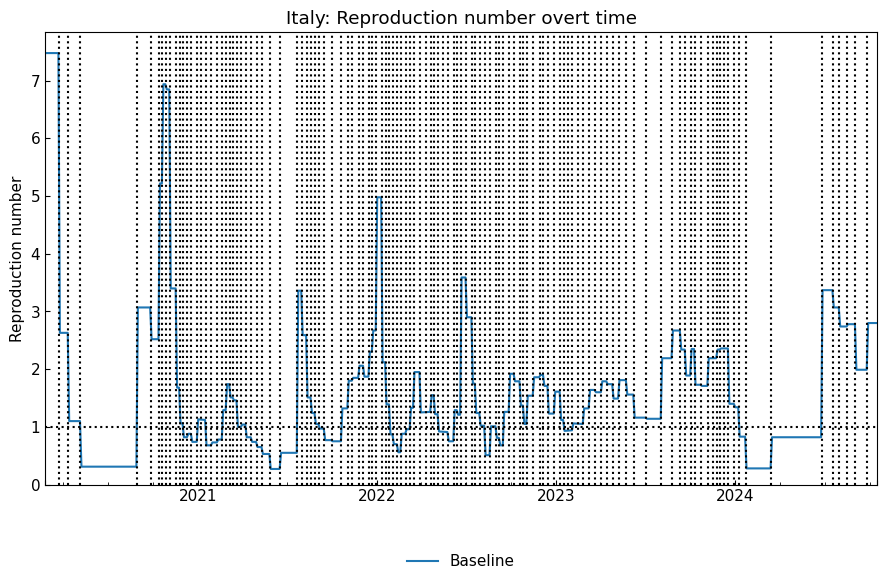

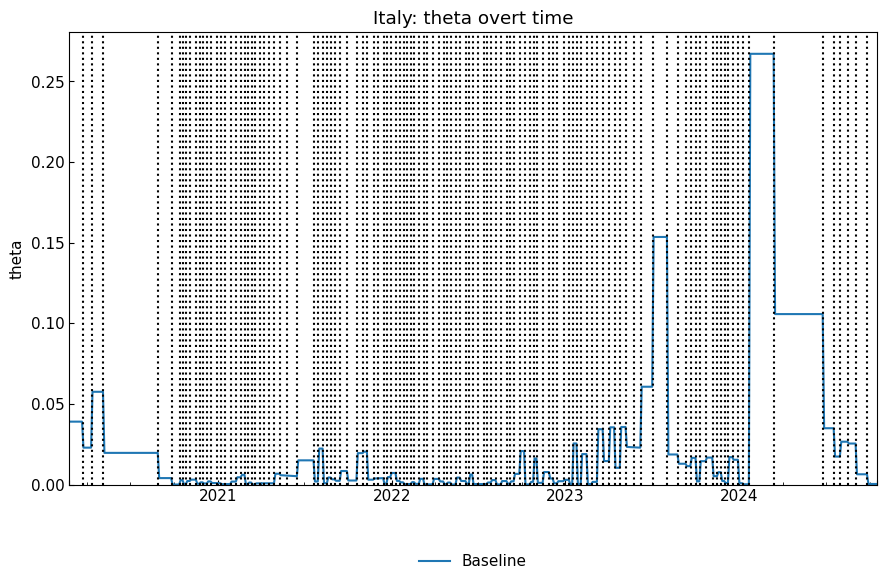

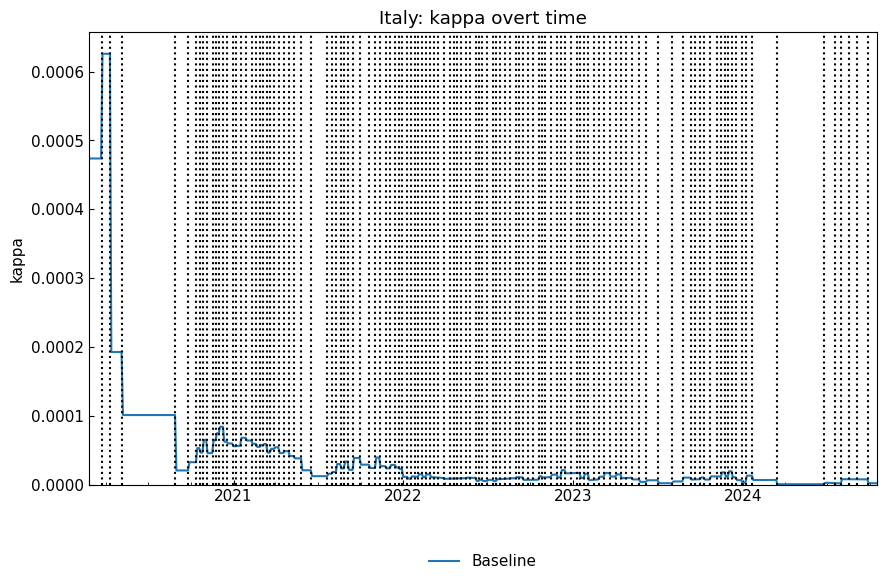

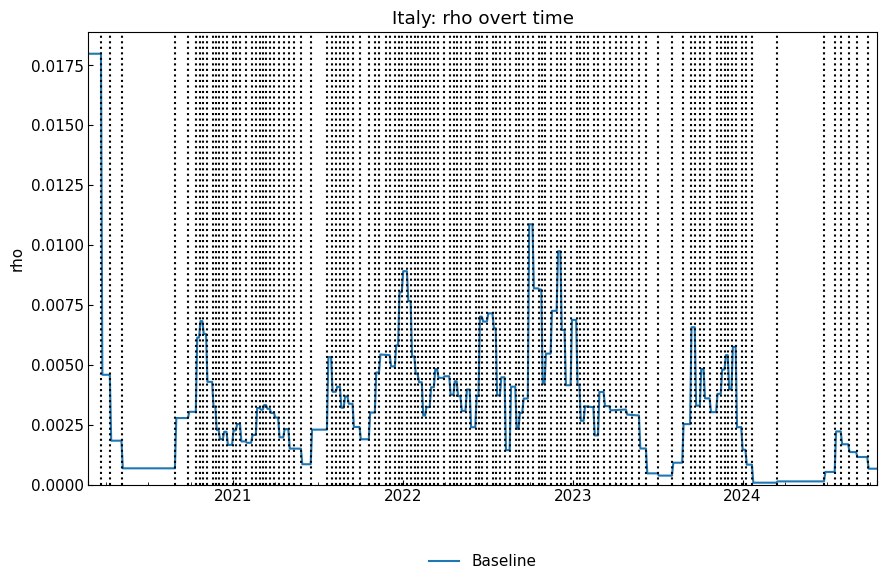

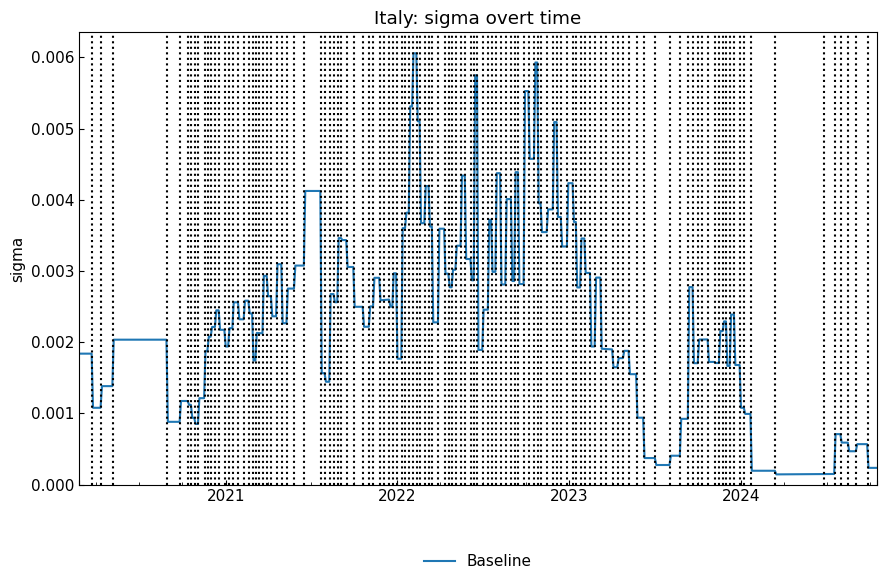

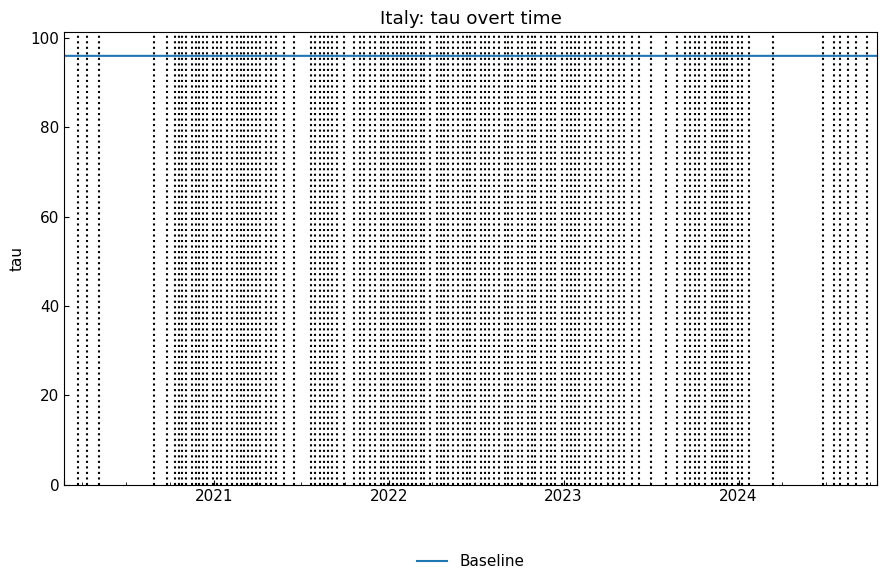

Scenario,Baseline
Date,
2020-02-24,96
2020-02-25,96
2020-02-26,96
2020-02-27,96
2020-02-28,96
...,...
2024-10-12,96
2024-10-13,96
2024-10-14,96


In [20]:
scenario.compare_param("Rt")
scenario.compare_param("theta")
scenario.compare_param("kappa")
scenario.compare_param("rho")
scenario.compare_param("sigma")
scenario.compare_param("tau")

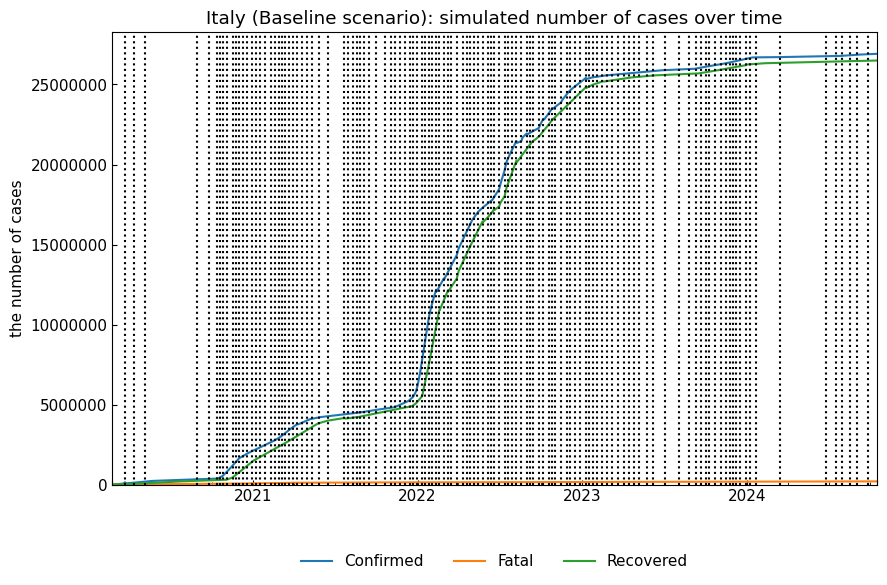

,Confirmed,Fatal,Recovered
Date,,,
2020-02-24,229.0,7.0,1.0
2020-02-25,296.0,11.0,8.0
2020-02-26,379.0,17.0,16.0
2020-02-27,485.0,24.0,27.0
2020-02-28,616.0,32.0,41.0
...,...,...,...
2024-10-12,26912605.0,197747.0,26495872.0
2024-10-13,26913814.0,197754.0,26496643.0
2024-10-14,26915023.0,197760.0,26497415.0


In [21]:
scenario.simulate(name="Baseline")

In [22]:
future_start_date = scenario.simulate(display=False).index.max() + timedelta(days=1)

scenario.build_with_template(name="Predicted", template="Baseline");
scenario.predict(days=7, name="Predicted")

df = scenario.append().summary()
df.loc[df["Start"] >= future_start_date]

,,Start,End,Rt,theta,kappa,rho,sigma,alpha1 [-],1/alpha2 [day],1/beta [day],1/gamma [day],ODE,tau
Scenario,Phase,,,,,,,,,,,,,
Predicted,124th,2024-10-17,2024-10-23,2.8,0.000418,0.000002,0.000662,0.000234,0.0,34179,101,284,SIR-F Model,96


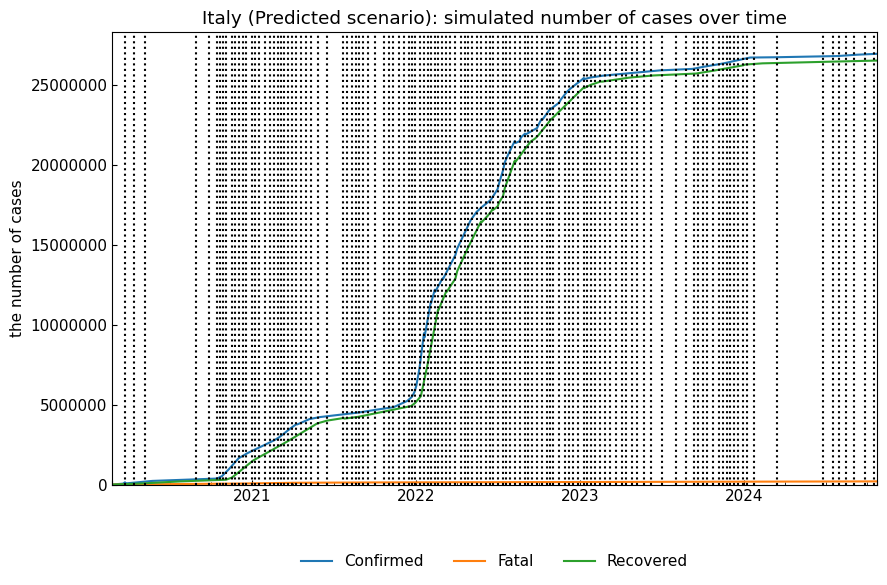

,Confirmed,Fatal,Recovered
Date,,,
2020-02-24,229.0,7.0,1.0
2020-02-25,296.0,11.0,8.0
2020-02-26,379.0,17.0,16.0
2020-02-27,485.0,24.0,27.0
2020-02-28,616.0,32.0,41.0
...,...,...,...
2024-10-19,26921110.0,197795.0,26501298.0
2024-10-20,26922334.0,197802.0,26502079.0
2024-10-21,26923561.0,197809.0,26502862.0


In [23]:
scenario.simulate(name="Predicted")

In [24]:
future_start_date = scenario.simulate(display=False).index.max() + timedelta(days=1)

scenario.build_with_template(name="Predicted", template="Baseline");
scenario.predict(days=30, name="Predicted")

df = scenario.append().summary()
df.loc[df["Start"] >= future_start_date]

2025-12-21 at 19:50:43 | ERROR | validation of points failed
2025-12-21 at 19:50:43 | ERROR | validation of end failed
2025-12-21 at 19:50:43 | ERROR | validation of points failed
2025-12-21 at 19:50:43 | ERROR | validation of end failed
2025-12-21 at 19:50:43 | ERROR | validation of points failed
2025-12-21 at 19:50:43 | ERROR | validation of end failed
2025-12-21 at 19:50:43 | ERROR | validation of points failed
2025-12-21 at 19:50:43 | ERROR | validation of end failed
2025-12-21 at 19:50:43 | ERROR | validation of points failed
2025-12-21 at 19:50:43 | ERROR | validation of end failed
2025-12-21 at 19:50:43 | ERROR | validation of points failed
2025-12-21 at 19:50:43 | ERROR | validation of end failed
2025-12-21 at 19:50:43 | ERROR | validation of points failed
2025-12-21 at 19:50:43 | ERROR | validation of end failed
2025-12-21 at 19:50:43 | ERROR | validation of points failed
2025-12-21 at 19:50:43 | ERROR | validation of end failed
2025-12-21 at 19:50:44 | ERROR | validation of p

Start        End    Rt  theta     kappa       rho  \
Scenario  Phase                                                          
Predicted 124th 2024-10-24 2024-10-26  2.51    0.0  0.000003  0.000585   
          125th 2024-10-27 2024-10-29  2.49    0.0  0.000003  0.000566   
          126th 2024-10-30 2024-11-01  2.62    0.0  0.000003  0.000579   
          127th 2024-11-02 2024-11-04  2.44    0.0  0.000003  0.000525   
          128th 2024-11-05 2024-11-07  2.19    0.0  0.000003  0.000458   
          129th 2024-11-08 2024-11-10  2.26    0.0  0.000004  0.000461   
          130th 2024-11-11 2024-11-13  2.33    0.0  0.000003  0.000457   
          131st 2024-11-14 2024-11-17  2.02    0.0  0.000004  0.000384   
          132nd 2024-11-18 2024-11-20  2.11    0.0  0.000004  0.000387   

                    sigma  alpha1 [-]  1/alpha2 [day]  1/beta [day]  \
Scenario  Phase                                                       
Predicted 124th   0.00023         0.0           25411           114   
          125th  0.000224         0.0           19996           118   
          126th  0.000218         0.0           24145           115   
          127th  0.000212         0.0           19208           127   
          128th  0.000206         0.0           21060           146   
          129th    0.0002         0.0           17016           145   
          130th  0.000194         0.0           22705           146   
          131st  0.000186         0.0           16501           174   
          132nd  0.000179         0.0           15359           172   

                 1/gamma [day]          ODE  tau  
Scenario  Phase                                   
Predicted 124th            289  SIR-F Model   96  
          125th            297  SIR-F Model   96  
          126th            306  SIR-F Model   96  
          127th            315  SIR-F Model   96  
          128th            324  SIR-F Model   96  
          129th            334  SIR-F Model   96  
          130th            344  SIR-F Model   96  
          131st            359  SIR-F Model   96  
          132nd            371  SIR-F Model   96

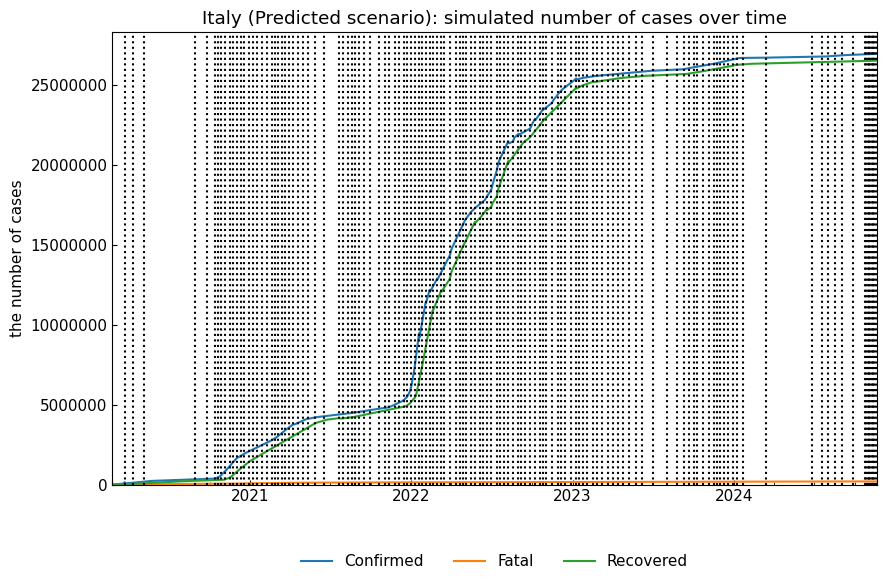

,Confirmed,Fatal,Recovered
Date,,,
2020-02-24,229.0,7.0,1.0
2020-02-25,296.0,11.0,8.0
2020-02-26,379.0,17.0,16.0
2020-02-27,485.0,24.0,27.0
2020-02-28,616.0,32.0,41.0
...,...,...,...
2024-11-16,26949270.0,198085.0,26521656.0
2024-11-17,26950002.0,198099.0,26522295.0
2024-11-18,26950735.0,198113.0,26522934.0


In [25]:
scenario.simulate(name="Predicted")

In [26]:
future_start_date = scenario.simulate(display=False).index.max() + timedelta(days=1)

scenario.build_with_template(name="Predicted", template="Baseline");
scenario.predict(days=100, name="Predicted")

df = scenario.append().summary()
df.loc[df["Start"] >= future_start_date]

2025-12-21 at 19:51:29 | ERROR | validation of points failed
2025-12-21 at 19:51:29 | ERROR | validation of end failed
2025-12-21 at 19:51:29 | ERROR | validation of points failed
2025-12-21 at 19:51:29 | ERROR | validation of end failed
2025-12-21 at 19:51:30 | ERROR | validation of points failed
2025-12-21 at 19:51:30 | ERROR | validation of end failed
2025-12-21 at 19:51:30 | ERROR | validation of points failed
2025-12-21 at 19:51:30 | ERROR | validation of end failed
2025-12-21 at 19:51:30 | ERROR | validation of points failed
2025-12-21 at 19:51:30 | ERROR | validation of end failed
2025-12-21 at 19:51:30 | ERROR | validation of points failed
2025-12-21 at 19:51:30 | ERROR | validation of end failed
2025-12-21 at 19:51:31 | ERROR | validation of points failed
2025-12-21 at 19:51:31 | ERROR | validation of end failed
2025-12-21 at 19:51:31 | ERROR | validation of points failed
2025-12-21 at 19:51:31 | ERROR | validation of end failed
2025-12-21 at 19:51:32 | ERROR | validation of p

Start        End    Rt     theta     kappa       rho  \
Scenario  Phase                                                             
Predicted 124th 2024-11-21 2024-11-24  2.55  0.000363  0.000002  0.000546   
          125th 2024-11-25 2024-11-29  2.56  0.000363  0.000002  0.000542   
          126th 2024-11-30 2024-12-04  2.58  0.000363  0.000002  0.000535   
          127th 2024-12-05 2024-12-07   2.6  0.000363  0.000002  0.000528   
          128th 2024-12-08 2024-12-11  2.62  0.000363  0.000002  0.000518   
          129th 2024-12-12 2024-12-14  2.64  0.000363  0.000002  0.000508   
          130th 2024-12-15 2024-12-17  2.66  0.000363  0.000002  0.000498   
          131st 2024-12-18 2024-12-20  2.68  0.000363  0.000002  0.000487   
          132nd 2024-12-21 2024-12-23   2.7  0.000363  0.000002  0.000475   
          133rd 2024-12-24 2024-12-28  2.72  0.000363  0.000002  0.000452   
          134th 2024-12-29 2025-01-01  2.73  0.000363  0.000002  0.000433   
          135th 2025-01-02 2025-01-06  2.74  0.000363  0.000002  0.000408   
          136th 2025-01-07 2025-01-10  2.73  0.000363  0.000002  0.000387   
          137th 2025-01-11 2025-01-13  2.72  0.000363  0.000002  0.000371   
          138th 2025-01-14 2025-01-16   2.7  0.000363  0.000002  0.000355   
          139th 2025-01-17 2025-01-20  2.68  0.000363  0.000002  0.000334   
          140th 2025-01-21 2025-01-23  2.66  0.000363  0.000002  0.000319   
          141st 2025-01-24 2025-01-27  2.64  0.000363  0.000002    0.0003   
          142nd 2025-01-28 2025-01-31  2.62  0.000363  0.000002  0.000281   
          143rd 2025-02-01 2025-02-03  2.61  0.000363  0.000002  0.000269   
          144th 2025-02-04 2025-02-13   2.6  0.000363  0.000002  0.000236   
          145th 2025-02-14 2025-02-17  2.61  0.000363  0.000002  0.000227   
          146th 2025-02-18 2025-02-22  2.62  0.000363  0.000002  0.000219   
          147th 2025-02-23 2025-02-28  2.63  0.000363  0.000002  0.000216   

                    sigma  alpha1 [-]  1/alpha2 [day]  1/beta [day]  \
Scenario  Phase                                                       
Predicted 124th  0.000212         0.0           32992           122   
          125th  0.000209         0.0           32928           123   
          126th  0.000205         0.0           32806           125   
          127th  0.000201         0.0           32709           126   
          128th  0.000195         0.0           32559           129   
          129th   0.00019         0.0           32436           131   
          130th  0.000185         0.0           32306           134   
          131st  0.000179         0.0           32174           137   
          132nd  0.000174         0.0           32042           140   
          133rd  0.000164         0.0           31826           147   
          134th  0.000156         0.0           31660           154   
          135th  0.000147         0.0           31462           163   
          136th   0.00014         0.0           31310           172   
          137th  0.000134         0.0           31198           180   
          138th  0.000129         0.0           31089           188   
          139th  0.000123         0.0           30943           199   
          140th  0.000118         0.0           30834           209   
          141st  0.000111         0.0           30688           223   
          142nd  0.000105         0.0           30542           237   
          143rd  0.000101         0.0           30435           248   
          144th  0.000088         0.0           30114           282   
          145th  0.000085         0.0           30015           294   
          146th  0.000081         0.0           29928           304   
          147th   0.00008         0.0           29886           309   

                 1/gamma [day]          ODE  tau  
Scenario  Phase                                   
Predicted 124th            315  SIR-F Model   96  
          125th   

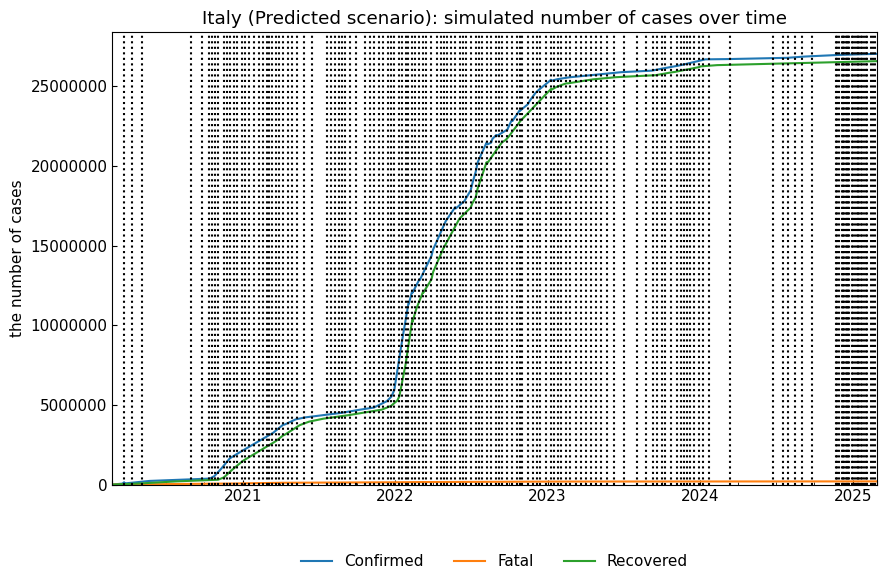

,Confirmed,Fatal,Recovered
Date,,,
2020-02-24,229.0,7.0,1.0
2020-02-25,296.0,11.0,8.0
2020-02-26,379.0,17.0,16.0
2020-02-27,485.0,24.0,27.0
2020-02-28,616.0,32.0,41.0
...,...,...,...
2025-02-24,27038881.0,198817.0,26579110.0
2025-02-25,27039347.0,198826.0,26579422.0
2025-02-26,27039815.0,198835.0,26579735.0


In [27]:
scenario.simulate(name="Predicted")